In [ ]:
# install libraries

%pip install pandas
%pip install scikit-learn
%pip install numpy
%pip install torch

In [ ]:
# =====================================================
# SYNTHETIC MIMIC ANALYSIS PROJECT
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

Mounted at /content/drive


In [ ]:
# load datasets
# -----------------------------------------------------

print("Loading datasets...")
print()

patients = pd.read_csv(
    f"{DATA_PATH}/patients.csv"
)

admissions = pd.read_csv(
    f"{DATA_PATH}/admissions.csv"
)

icu = pd.read_csv(
    f"{DATA_PATH}/icu_stays.csv"
)

diagnoses = pd.read_csv(
    f"{DATA_PATH}/diagnoses.csv"
)

procedures = pd.read_csv(
    f"{DATA_PATH}/procedures.csv"
)

medications = pd.read_csv(
    f"{DATA_PATH}/medications.csv"
)

labs = pd.read_csv(
    f"{DATA_PATH}/labs.csv"
)

comorbidities = pd.read_csv(
    f"{DATA_PATH}/comorbidities.csv"
)

outcomes = pd.read_csv(
    f"{DATA_PATH}/outcomes.csv"
)

print("All datasets loaded successfully.")
print()

# check dataset size
print("Dataset Shapes")
print("---------------------")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU:", icu.shape)
print("Diagnoses:", diagnoses.shape)
print("Procedures:", procedures.shape)
print("Medications:", medications.shape)
print("Labs:", labs.shape)
print("Comorbidities:", comorbidities.shape)
print("Outcomes:", outcomes.shape)

# preview data
print()
print("Patients Preview: " + patients.head().to_string())

print()
print("Admissions Preview: " + admissions.head().to_string())

Loading datasets...

All datasets loaded successfully.

Dataset Shapes
---------------------
Patients: (10200, 4)
Admissions: (25059, 7)
ICU: (25059, 4)
Diagnoses: (74810, 4)
Procedures: (62542, 2)
Medications: (100576, 3)
Labs: (363744, 3)
Comorbidities: (19961, 2)
Outcomes: (25059, 7)

Patients Preview:    subject_id  anchor_age gender      race
0      100000          69   Male     ASIAN
1      100001          32      F  HISPANIC
2      100002          89      F       NaN
3      100003          78      F     WHITE
4      100004          38      M     OTHER

Admissions Preview:    hadm_id  subject_id   admittime   dischtime  los_days admission_type discharge_location
0   200000      100000  2022-01-06  2022-01-23        17         URGENT            EXPIRED
1   200001      100000  2019-11-08  2019-11-20        12       ELECTIVE               HOME
2   200002      100000  2023-09-04  2023-09-23        19       ELECTIVE              REHAB
3   200003      100000  2023-06-14  2023-06-28    

In [ ]:
# data cleaning
# =====================================================

# remove duplicates
print()
print("Removing duplicate rows...")

patients = patients.drop_duplicates()
admissions = admissions.drop_duplicates()
icu = icu.drop_duplicates()
diagnoses = diagnoses.drop_duplicates()
procedures = procedures.drop_duplicates()
medications = medications.drop_duplicates()
labs = labs.drop_duplicates()

print("Duplicates removed.")


# handling missing race values
print()
print("Filling missing race values...")

patients["race"] = patients["race"].fillna(
    "UNKNOWN"
)

# standdarize gender values
print()
print("Cleaning gender values...")

patients["gender"] = patients["gender"].replace({
    "Male": "M",
    "Female": "F"
})


# convert lab values to numeric
print()
print("Converting lab values to numeric...")

labs["lab_value"] = pd.to_numeric(
    labs["lab_value"],
    errors="coerce"
)


# fill missing lab values
print()
print("Replacing missing lab values with median...")

for lab_name in labs["lab_name"].unique():

    median_value = labs.loc[
        labs["lab_name"] == lab_name,
        "lab_value"
    ].median()

    labs.loc[
        (labs["lab_name"] == lab_name) &
        (labs["lab_value"].isna()),
        "lab_value"
    ] = median_value


# convert data columns
print()
print("Converting date columns...")

admissions["admittime"] = pd.to_datetime(
    admissions["admittime"]
)

admissions["dischtime"] = pd.to_datetime(
    admissions["dischtime"]
)

print()
print("Cleaning completed.")


# check cleaned data
print()
print("Patients Shape After Cleaning: " + str(patients.shape))

print()
print("Admissions Shape After Cleaning: " + str(admissions.shape))

print()
print("Labs Shape After Cleaning: " + str(labs.shape))


Removing duplicate rows...
Duplicates removed.

Filling missing race values...

Cleaning gender values...

Converting lab values to numeric...

Replacing missing lab values with median...

Converting date columns...

Cleaning completed.

Patients Shape After Cleaning: (10000, 4)

Admissions Shape After Cleaning: (25059, 7)

Labs Shape After Cleaning: (362307, 3)


In [ ]:
# create master dataset
# =====================================================

# merge admissions + patients
print()
print("Merging admissions and patients...")

master = pd.merge(
    admissions,
    patients,
    on="subject_id",
    how="left"
)

print("Shape after first merge: " + str(master.shape))


# merge ICU data
print()
print("Adding ICU information...")

master = pd.merge(
    master,
    icu,
    on=["hadm_id", "subject_id"],
    how="left"
)

print("Shape after ICU merge: " + str(master.shape))


# merge ouctcomes data
print()
print("Adding outcomes information...")

master = pd.merge(
    master,
    outcomes,
    on=["hadm_id", "los_days"],
    how="left"
)

print("Shape after outcomes merge: " + str(master.shape))


# master dataset check
# =====================================================

print()
print("====================================")
print("MASTER DATASET SUMMARY")
print("====================================")

print()
print("Rows and Columns: " + str(master.shape))

print()
print("Column Names: " + str(master.columns.tolist()))

print()
print("Preview of Master Dataset: " + master.head().to_string())

# check for missing values
print()
print("Missing Values Per Column")

missing_values = master.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

print()
print("Master dataset successfully created.")


Merging admissions and patients...
Shape after first merge: (25059, 10)

Adding ICU information...
Shape after ICU merge: (25059, 12)

Adding outcomes information...
Shape after outcomes merge: (25059, 17)

MASTER DATASET SUMMARY

Rows and Columns: (25059, 17)

Column Names: ['hadm_id', 'subject_id', 'admittime', 'dischtime', 'los_days', 'admission_type', 'discharge_location', 'anchor_age', 'gender', 'race', 'icu_los', 'sofa', 'mortality', 'mortality_90d', 'readmit_30d', 'sepsis', 'ventilation']

Preview of Master Dataset:    hadm_id  subject_id  admittime  dischtime  los_days admission_type discharge_location  anchor_age gender      race  icu_los  sofa  mortality  mortality_90d  readmit_30d  sepsis  ventilation
0   200000      100000 2022-01-06 2022-01-23        17         URGENT            EXPIRED          69      M     ASIAN     1.68     5          0              0            0       0            0
1   200001      100000 2019-11-08 2019-11-20        12       ELECTIVE               

In [ ]:
# count features
# =====================================================

# count how many diagnoses each admission has
diag_counts = diagnoses.groupby(
    "hadm_id"
).size()

# convert result into dataframe
diag_counts = diag_counts.reset_index()

# rename columns
diag_counts.columns = [
    "hadm_id",
    "num_diagnoses"
]

print()
print(diag_counts.head())

# count how many procedures each admission has
proc_counts = procedures.groupby(
    "hadm_id"
).size()

# convert result into dataframe
proc_counts = proc_counts.reset_index()

# rename columns
proc_counts.columns = [
    "hadm_id",
    "num_procedures"
]

print()
print(proc_counts.head())

# count how many medications each admission has
med_counts = medications.groupby(
    "hadm_id"
).size()

# convert result into dataframe
med_counts = med_counts.reset_index()

# rename columns
med_counts.columns = [
    "hadm_id",
    "num_medications"
]

print()
print(med_counts.head())

# count how many labs each admission has
lab_counts = labs.groupby(
    "hadm_id"
).size()

# convert result into dataframe
lab_counts = lab_counts.reset_index()

# rename columns
lab_counts.columns = [
    "hadm_id",
    "num_labs"
]

print()
print(lab_counts.head())


# merge counts into master datatset
print()
print("Adding diagnosis counts to master dataset...")

master = pd.merge(
    master,
    diag_counts,
    on="hadm_id",
    how="left"
)

print("Shape: ", master.shape)

print()
print("Adding procedure counts to master dataset...")

master = pd.merge(
    master,
    proc_counts,
    on="hadm_id",
    how="left"
)

print("Shape: ", master.shape)

print()
print("Adding medication counts to master dataset...")

master = pd.merge(
    master,
    med_counts,
    on="hadm_id",
    how="left"
)

print("Shape: ", master.shape)

print()
print("Adding lab counts to master dataset...")

master = pd.merge(
    master,
    lab_counts,
    on="hadm_id",
    how="left"
)

print("Shape: ", master.shape)


   hadm_id  num_diagnoses
0   200000              4
1   200001              4
2   200002              5
3   200003              3
4   200004              1

   hadm_id  num_procedures
0   200000               1
1   200001               2
2   200002               4
3   200003               3
4   200004               3

   hadm_id  num_medications
0   200000                3
1   200001                4
2   200002                3
3   200003                5
4   200004                4

   hadm_id  num_labs
0   200000        15
1   200001        12
2   200002        24
3   200003        20
4   200004        11

Adding diagnosis counts to master dataset...
Shape:  (25059, 18)

Adding procedure counts to master dataset...
Shape:  (25059, 19)

Adding medication counts to master dataset...
Shape:  (25059, 20)

Adding lab counts to master dataset...
Shape:  (25059, 21)


In [ ]:
# lab summary features
# =====================================================

# average lab value
mean_lab = labs.groupby(
    "hadm_id"
)["lab_value"].mean()

# convert result into dataframe
mean_lab = mean_lab.reset_index()

mean_lab.columns = [
    "hadm_id",
    "mean_lab"
]

# maximum lab value
max_lab = labs.groupby(
    "hadm_id"
)["lab_value"].max()

# convert result into dataframe
max_lab = max_lab.reset_index()

max_lab.columns = [
    "hadm_id",
    "max_lab"
]

# minimum lab value
min_lab = labs.groupby(
    "hadm_id"
)["lab_value"].min()

# convert result into dataframe
min_lab = min_lab.reset_index()

min_lab.columns = [
    "hadm_id",
    "min_lab"
]

# standard deviation
std_lab = labs.groupby(
    "hadm_id"
)["lab_value"].std()

# convert result into dataframe
std_lab = std_lab.reset_index()

std_lab.columns = [
    "hadm_id",
    "std_lab"
]

# merge each feature separately
master = pd.merge(
    master,
    mean_lab,
    on="hadm_id",
    how="left"
)

master = pd.merge(
    master,
    max_lab,
    on="hadm_id",
    how="left"
)

master = pd.merge(
    master,
    min_lab,
    on="hadm_id",
    how="left"
)

master = pd.merge(
    master,
    std_lab,
    on="hadm_id",
    how="left"
)

print()
print("Lab features added.")


Lab features added.


In [ ]:
# comorbidities
# =====================================================

# create a matrix so each disease becomes a column
comorb_matrix = pd.crosstab(
    comorbidities["subject_id"],
    comorbidities["condition"]
)

# convert index back into a normal column
comorb_matrix = comorb_matrix.reset_index()

print()
print(comorb_matrix.head())

# merge into master dataset
master = pd.merge(
    master,
    comorb_matrix,
    on="subject_id",
    how="left"
)

print()
print("Shape: ", master.shape)


condition  subject_id  CHF  CKD  COPD  Diabetes  Hypertension
0              100000    0    0     1         0             0
1              100001    0    1     1         0             0
2              100002    0    0     0         1             1
3              100003    0    0     0         0             1
4              100004    0    0     1         0             1

Shape:  (25059, 30)


In [ ]:
# handle missing values
# =====================================================

master = master.fillna(0)

print("Missing values replaced with 0.")

Missing values replaced with 0.


In [ ]:
# feature engineering
# =====================================================

# resource score estimates how many resources were used during an admission
master["resource_score"] = (
    master["num_labs"] +
    master["num_medications"] +
    master["num_procedures"]
)

print("Resource score created.")


# calculate median length of stay
median_los = master["los_days"].median()

# initialize new column
master["long_stay"] = 0

# patients above median LOS are long stay
master.loc[
    master["los_days"] > median_los,
    "long_stay"
] = 1

print("Long stay variable created.")


# high resource flag
median_resource = master[
    "resource_score"
].median()

master["high_resource_patient"] = 0

master.loc[
    master["resource_score"] > median_resource,
    "high_resource_patient"
] = 1

print("High resource variable created.")


# Charlson index
# simplified comorbidity score
master["charlson_index"] = (
    master["num_diagnoses"] * 0.8
)

print("Charlson index created.")


# age groups
master["age_group"] = pd.cut(
    master["anchor_age"],
    bins=[0, 40, 60, 80, 120],
    labels=[
        "18-40",
        "41-60",
        "61-80",
        "80+"
    ]
)

print("Age groups created.")


# feature check
new_features = [
    "resource_score",
    "long_stay",
    "high_resource_patient",
    "charlson_index",
    "age_group"
]

print(
    master[
        new_features
    ].head()
)

Resource score created.
Long stay variable created.
High resource variable created.
Charlson index created.
Age groups created.
   resource_score  long_stay  high_resource_patient  charlson_index age_group
0              19          1                      0             3.2     61-80
1              18          1                      0             3.2     61-80
2              31          1                      1             4.0     61-80
3              28          1                      1             2.4     61-80
4              18          0                      0             0.8     18-40


In [ ]:
# hospital KPIs
# =====================================================

# avergae length of stay
average_los = master["los_days"].mean()

print()
print("Average Length of Stay: " + str(average_los))


# median length of stay
median_los = master["los_days"].median()

print()
print("Median Length of Stay: " + str(median_los))


# readmission rate
readmission_rate = master[
    "readmit_30d"
].mean()

print()
print("30-Day Readmission Rate: " + str(readmission_rate))


# hospital mortality rate
mortality_rate = master[
    "mortality"
].mean()

print()
print("Hospital Mortality Rate: " + str(mortality_rate))


# average ICU length of stay
average_icu_los = master[
    "icu_los"
].mean()

print()
print("Average ICU Length of Stay: " + str(average_icu_los))


Average Length of Stay: 10.002793407558162

Median Length of Stay: 10.0

30-Day Readmission Rate: 0.14860928209425756

Hospital Mortality Rate: 0.09964483818189074

Average ICU Length of Stay: 3.9917115607167086


In [ ]:
# bottleneck analysis
# =====================================================

# length of stay by admission type
print()
print("Average LOS by Admission Type")

los_by_admission = master.groupby(
    "admission_type"
)["los_days"].mean()

los_by_admission = los_by_admission.sort_values(
    ascending=False
)

print(los_by_admission)

# resource use by admission type
print()
print("Average Resource Use by Admission Type")

resource_by_admission = master.groupby(
    "admission_type"
)["resource_score"].mean()

resource_by_admission = resource_by_admission.sort_values(
    ascending=False
)

print(resource_by_admission)

# highest resource consuming group
highest_resource_group = (
    resource_by_admission.index[0]
)

print()
print("Highest Resource Use Category: " + str(highest_resource_group))


# longest stay group
longest_stay_group = (
    los_by_admission.index[0]
)

print()
print("Longest Stay Category: " + str(longest_stay_group))


Average LOS by Admission Type
admission_type
OBSERVATION    10.067832
URGENT         10.059581
ELECTIVE        9.993051
EMERGENCY       9.891896
Name: los_days, dtype: float64

Average Resource Use by Admission Type
admission_type
OBSERVATION    20.428801
EMERGENCY      20.427002
URGENT         20.331240
ELECTIVE       20.275111
Name: resource_score, dtype: float64

Highest Resource Use Category: OBSERVATION

Longest Stay Category: OBSERVATION



Creating LOS Distribution Plot...


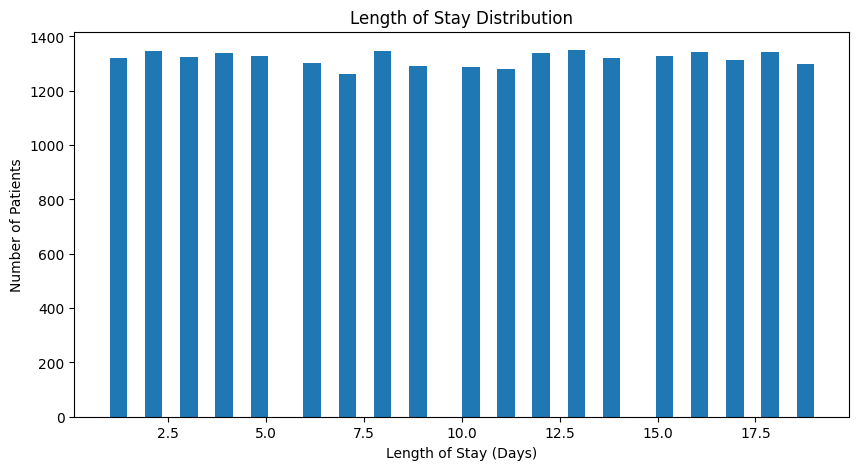


Creating Resource Score Plot...


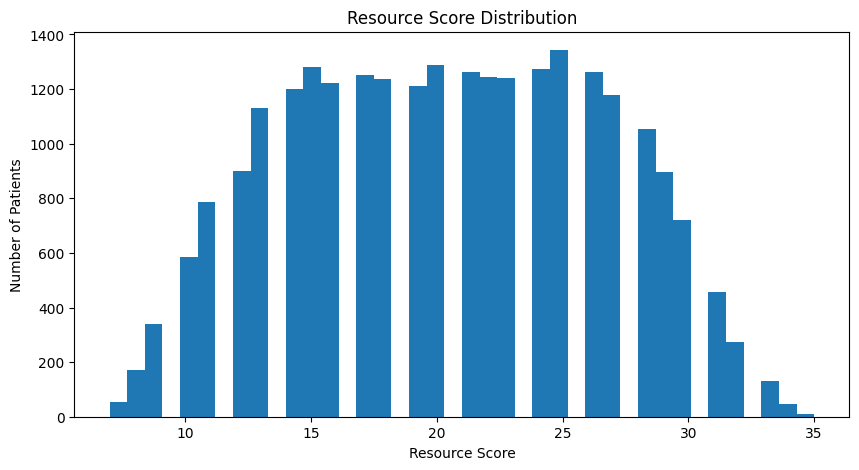


Creating Age Group LOS Plot...


/tmp/ipykernel_490/2234564680.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  los_by_age = master.groupby(


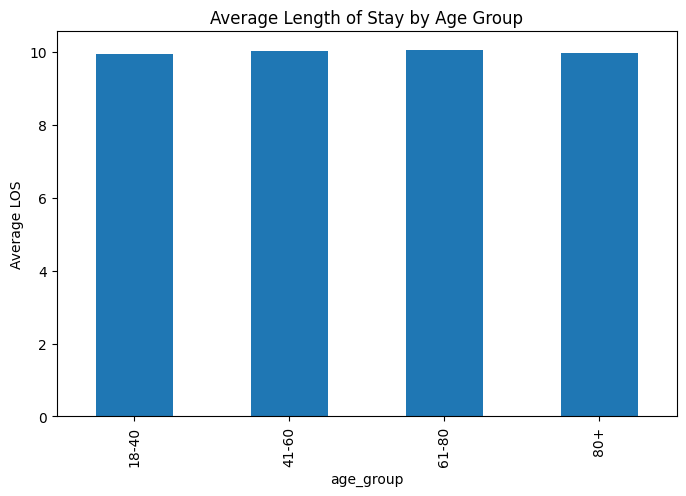

In [ ]:
# visualizations
# =====================================================

# length of stay distribution
print()
print("Creating LOS Distribution Plot...")

plt.figure(figsize=(10,5))

plt.hist(
    master["los_days"],
    bins=40
)

plt.title(
    "Length of Stay Distribution"
)

plt.xlabel(
    "Length of Stay (Days)"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()


# resource score distribution
print()
print("Creating Resource Score Plot...")

plt.figure(figsize=(10,5))

plt.hist(
    master["resource_score"],
    bins=40
)

plt.title(
    "Resource Score Distribution"
)

plt.xlabel(
    "Resource Score"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()



# los by age group
print()
print("Creating Age Group LOS Plot...")

los_by_age = master.groupby(
    "age_group"
)["los_days"].mean()

plt.figure(figsize=(8,5))

los_by_age.plot(
    kind="bar"
)

plt.title(
    "Average Length of Stay by Age Group"
)

plt.ylabel(
    "Average LOS"
)

plt.show()

In [ ]:
# additional summary statistics
# =====================================================
print()
print("Length of Stay Statistics")
print(
    master["los_days"].describe()
)

print()
print("Resource Score Statistics")
print(
    master["resource_score"].describe()
)

print()
print("ICU Length of Stay Statistics")
print(
    master["icu_los"].describe()
)


# dataset chepoint
print()
print("Current Dataset Shape")
print(master.shape)


Length of Stay Statistics
count    25059.000000
mean        10.002793
std          5.489248
min          1.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         19.000000
Name: los_days, dtype: float64

Resource Score Statistics
count    25059.000000
mean        20.365338
std          6.107532
min          7.000000
25%         15.000000
50%         20.000000
75%         25.000000
max         35.000000
Name: resource_score, dtype: float64

ICU Length of Stay Statistics
count    25059.000000
mean         3.991712
std          2.809005
min          0.010000
25%          1.950000
50%          3.360000
75%          5.320000
max         31.700000
Name: icu_los, dtype: float64

Current Dataset Shape
(25059, 35)
